# Problem Set 2
# Juan Pablo Brasdefer
## October 2024
## Applied Neural Networks - prof. Ziogas

In [4]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import accuracy_score
import tarfile # extracting tgz file
import scipy.io # load id setting
import os # working with operating system
from tensorflow.keras.preprocessing.image import load_img, img_to_array # image imports
from tensorflow.keras.utils import to_categorical # one hot encoding
from tensorflow import keras # CNN from scratch
from tensorflow.keras import layers, models # CNN from scratch
from tensorflow.keras.utils import image_dataset_from_directory # directory navigation, images to tensors

import json
from tensorflow.keras.preprocessing.image import ImageDataGenerator # generate data with low storage requirement
from sklearn.model_selection import train_test_split # split data
from sklearn.preprocessing import LabelBinarizer # labels
import cv2 # work with csvs

import pandas as pd
from PIL import Image


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Task 1 - Oxford Flowers

In [ ]:
# import tarfile
# extract the 102flowers.tgz file
with tarfile.open('/content/drive/MyDrive/ColabNotebooks/GU_Data/102flowers.tgz', 'r:gz') as tar:
    tar.extractall('flowers')  # Extract to 'flowers' directory

In [ ]:
#import scipy.io
# load label data
labels_data = scipy.io.loadmat('/content/drive/MyDrive/ColabNotebooks/GU_Data/imagelabels.mat')
labels = labels_data['labels'][0]  # extract the labels (1D array)

# load ids for sets
setid_data = scipy.io.loadmat('/content/drive/MyDrive/ColabNotebooks/GU_Data/setid.mat')
train_ids = setid_data['trnid'][0]  # training set image indices
val_ids = setid_data['valid'][0]    # validation set image indices
test_ids = setid_data['tstid'][0]   # rest set image indices

In [ ]:
# set directory for images to be extracted
image_dir = 'flowers/jpg'

# def load and preprocess images
def load_image(img_id, target_size=(180, 180)): #img size
    img_path = os.path.join(image_dir, f'image_{img_id:05d}.jpg')
    img = load_img(img_path, target_size=target_size)
    img_array = img_to_array(img)
    return img_array



In [ ]:
# load the datasets using the image indices
def create_dataset(image_ids, labels, target_size=(180, 180)):
    images = np.array([load_image(img_id, target_size=target_size) for img_id in image_ids])
    labels = np.array([labels[img_id - 1] for img_id in image_ids])  # Image IDs start from 1, so adjust index
    return images, labels

# assign the train, validation, and test sets
train_dataset, train_labels = create_dataset(train_ids, labels)
val_dataset, val_labels = create_dataset(val_ids, labels)
test_dataset, test_labels = create_dataset(test_ids, labels)


# convert labels to one-hot encoding
train_labels = to_categorical(train_labels - 1, num_classes=102)  # subtract 1 because labels are 1-based
val_labels = to_categorical(val_labels - 1, num_classes=102)
test_labels = to_categorical(test_labels - 1, num_classes=102)

In [ ]:
# load a sample image to make sure it works

#sample_image = load_image(train_ids[0])
#sample_image

array([[[ 10.,  21.,   7.],
        [ 12.,  25.,   7.],
        [ 21.,  37.,  11.],
        ...,
        [105.,  80., 101.],
        [144., 103., 159.],
        [143., 101., 151.]],

       [[ 15.,  23.,  10.],
        [ 14.,  25.,   8.],
        [ 21.,  35.,  12.],
        ...,
        [111.,  83., 105.],
        [145., 102., 158.],
        [141.,  99., 147.]],

       [[ 18.,  24.,  12.],
        [ 17.,  26.,   9.],
        [ 17.,  29.,   9.],
        ...,
        [117.,  87., 111.],
        [145., 100., 157.],
        [141.,  97., 146.]],

       ...,

       [[ 33.,  57.,  25.],
        [ 28.,  50.,  12.],
        [ 30.,  49.,  17.],
        ...,
        [119.,  99., 136.],
        [123., 103., 140.],
        [121., 101., 138.]],

       [[ 30.,  55.,  25.],
        [ 32.,  56.,  20.],
        [ 29.,  50.,  17.],
        ...,
        [128., 111., 147.],
        [120., 100., 137.],
        [121.,  99., 137.]],

       [[ 25.,  52.,  17.],
        [ 27.,  54.,  21.],
        [ 33.,  

In [ ]:
# finalize datasets

# set batch size
batch_size = 32

# convert to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_dataset, train_labels))
val_dataset = tf.data.Dataset.from_tensor_slices((val_dataset, val_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_dataset, test_labels))

# shuffle, batch, and prefetch for performance
train_dataset = train_dataset.shuffle(buffer_size=len(train_dataset)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)



# quick check
for data_batch, labels_batch in train_dataset:
  print("data batch shape:", data_batch.shape)
  print("labels batch shape:", labels_batch.shape)
  break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32, 102)


Model 1
Kernel size 3x3
Pooling size 2x2
5 Layers
Relu in convolutional and Softmax out

In [ ]:
inputs = keras.Input(shape=(180, 180, 3))  # size for our images, and 3 channels of input (RGB)
x = layers.Rescaling(1./255)(inputs)        # rescale the range of 255 for colour values to [0,1]

x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)     # First Conv layer. We instruct the model to use 32 3x3 filters. The activation function is ReLU. The stride is the default 1. No padding is used.
x = layers.MaxPooling2D(pool_size=2)(x)   # The pooling layer will reduce the size by 2. Technically, the command is to use a 2x2 window with a stride of 2 to downsample the feature maps (essentially halving the dimensions). No effect on channels.
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)     # Second Conv layer. Same as the first. Notice how the filters have doubled.
x = layers.MaxPooling2D(pool_size=2)(x)     # Second pooling layer. Same as the first.
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)   # Third Conv layer. Filters are doubled.
x = layers.MaxPooling2D(pool_size=2)(x)  # Third pooling layer. Same as the others.
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)    # Fourth Conv layer. Filters are doubled.
x = layers.MaxPooling2D(pool_size=2)(x)    # Fourth pooling layer. Same as the others.
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)    # Fifth and final Conv layer. Final filter number: 256.
x = layers.Flatten()(x) # flatten tensors for the final computation
outputs = layers.Dense(102, activation="softmax")(x) # dense (fully connected) output layer with softmax (multiclass classification)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 178, 178, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 89, 89, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 87, 87, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 43, 43, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 41, 41, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 18, 18, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 9, 9, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 7, 7, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 102)                 │       1,279,590 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,258,086 (8.61 MB)

 Trainable params: 2,258,086 (8.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the model
model.compile(loss="categorical_crossentropy",  # loss function for multiclass
              optimizer="rmsprop",  # optimizer that auto adjusts learning rate during backprop. Widely used in CNNs. (alternative to "adam").
              metrics=["accuracy"])            # Performance metric.

In [ ]:
# callback for best model
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/ColabNotebooks/GU_Callbacks/PS2_CNN_Vanilla.keras",
        save_best_only=True,
        monitor="val_loss")
]

# fit
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 117s 4s/step - accuracy: 0.0066 - loss: 4.6777 - val_accuracy: 0.0137 - val_loss: 4.6176
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.0174 - loss: 4.6125 - val_accuracy: 0.0206 - val_loss: 4.3582
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 112s 4s/step - accuracy: 0.0196 - loss: 4.2872 - val_accuracy: 0.0402 - val_loss: 4.1705
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.0446 - loss: 4.0993 - val_accuracy: 0.0461 - val_loss: 4.3004
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.0781 - loss: 3.9202 - val_accuracy: 0.0363 - val_loss: 4.4490
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.1450 - loss: 3.5534 - val_accuracy: 0.1098 - val_loss: 3.8279
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.2415 - loss: 2.9660 - val_accuracy: 0.1078 - val_loss: 3.9350
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.4276 - loss: 2.2550 - val_accuracy: 0.1382 - v

In [ ]:
# saving  metrics as json
with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_model1_history.json', 'w') as f:
    json.dump(history.history, f)

Model 2 - Playing with Kernel size

In [ ]:
inputs = keras.Input(shape=(180, 180, 3))  # size for our images, and 3 channels of input (RGB)
x = layers.Rescaling(1./255)(inputs)        # rescale the range of 255 for colour values to [0,1]

x = layers.Conv2D(filters=32, kernel_size=5, activation="relu")(x)     # First Conv layer. We instruct the model to use 32 3x3 filters. The activation function is ReLU. The stride is the default 1. No padding is used.
x = layers.MaxPooling2D(pool_size=2)(x)   # The pooling layer will reduce the size by 2. Technically, the command is to use a 2x2 window with a stride of 2 to downsample the feature maps (essentially halving the dimensions). No effect on channels.
x = layers.Conv2D(filters=64, kernel_size=5, activation="relu")(x)     # Second Conv layer. Same as the first. Notice how the filters have doubled.
x = layers.MaxPooling2D(pool_size=2)(x)     # Second pooling layer. Same as the first.
x = layers.Conv2D(filters=128, kernel_size=5, activation="relu")(x)   # Third Conv layer. Filters are doubled.
x = layers.MaxPooling2D(pool_size=2)(x)  # Third pooling layer. Same as the others.
x = layers.Conv2D(filters=256, kernel_size=5, activation="relu")(x)    # Fourth Conv layer. Filters are doubled.
x = layers.MaxPooling2D(pool_size=2)(x)    # Fourth pooling layer. Same as the others.
x = layers.Conv2D(filters=256, kernel_size=5, activation="relu")(x)    # Fifth and final Conv layer. Final filter number: 256.
x = layers.Flatten()(x) # flatten tensors for the final computation
outputs = layers.Dense(102, activation="softmax")(x) # dense (fully connected) output layer with softmax (multiclass classification)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
# compile the model
model.compile(loss="categorical_crossentropy",  # loss function for multiclass
              optimizer="rmsprop",  # optimizer that auto adjusts learning rate during backprop. Widely used in CNNs. (alternative to "adam").
              metrics=["accuracy"])            # Performance metric.



In [ ]:
# best model
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/ColabNotebooks/GU_Callbacks/PS2_CNN_Model2.keras",
        save_best_only=True,
        monitor="val_loss")
]

# fit
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 387ms/step - accuracy: 0.0066 - loss: 4.9578 - val_accuracy: 0.0118 - val_loss: 4.6236
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.0105 - loss: 4.6208 - val_accuracy: 0.0157 - val_loss: 4.4679
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.0148 - loss: 4.5458 - val_accuracy: 0.0127 - val_loss: 4.3246
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.0269 - loss: 4.4050 - val_accuracy: 0.0412 - val_loss: 4.2427
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.0549 - loss: 4.1643 - val_accuracy: 0.0461 - val_loss: 4.0854
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.0507 - loss: 4.0382 - val_accuracy: 0.0578 - val_loss: 4.0031
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.0846 - loss: 3.7965 - val_accuracy: 0.0353 - val_loss: 4.2477
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.0988 - loss: 3.6934 - val_accuracy: 0.0804 -

In [ ]:
# saving  metrics as json

with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_model2_history.json', 'w') as f:
    json.dump(history.history, f)

Model 3 -  Increase Strides and Padding

In [ ]:
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)

# apply padding to avoid shrinking too fast
# since we are now using a stride greater than 1
x = layers.Conv2D(filters=32, kernel_size=3, strides=2, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=64, kernel_size=3, strides=1, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=128, kernel_size=3, strides=2, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=256, kernel_size=3, strides=1, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=256, kernel_size=3, strides=1, padding="same", activation="relu")(x)
x = layers.Flatten()(x)

outputs = layers.Dense(102, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
# compile the model
model.compile(loss="categorical_crossentropy",  # loss function for multiclass
              optimizer="rmsprop",  # optimizer that auto adjusts learning rate during backprop. Widely used in CNNs. (alternative to "adam").
              metrics=["accuracy"])            # Performance metric.


In [ ]:
# best model
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/ColabNotebooks/GU_Callbacks/PS2_CNN_Model3.keras",
        save_best_only=True,
        monitor="val_loss")
]

# fit
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.0064 - loss: 4.6315 - val_accuracy: 0.0167 - val_loss: 4.6102
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.0171 - loss: 4.5445 - val_accuracy: 0.0225 - val_loss: 4.3873
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.0268 - loss: 4.2886 - val_accuracy: 0.0284 - val_loss: 4.1559
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0320 - loss: 4.1157 - val_accuracy: 0.0294 - val_loss: 4.4712
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.0646 - loss: 3.8854 - val_accuracy: 0.0824 - val_loss: 3.8314
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1093 - loss: 3.5249 - val_accuracy: 0.1373 - val_loss: 3.5936
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1644 - loss: 3.3052 - val_accuracy: 0.1451 - val_loss: 3.5112
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.2238 - loss: 3.0118 - val_accuracy: 0.1676 

In [ ]:
# saving metric data to json
with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_model3_history.json', 'w') as f:
    json.dump(history.history, f)

Comparing our 3 models

In [ ]:
# Load the history for each model
with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_model1_history.json', 'r') as f:
    loaded_history_model1 = json.load(f)

with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_model2_history.json', 'r') as f:
    loaded_history_model2 = json.load(f)

with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_model3_history.json', 'r') as f:
    loaded_history_model3 = json.load(f)





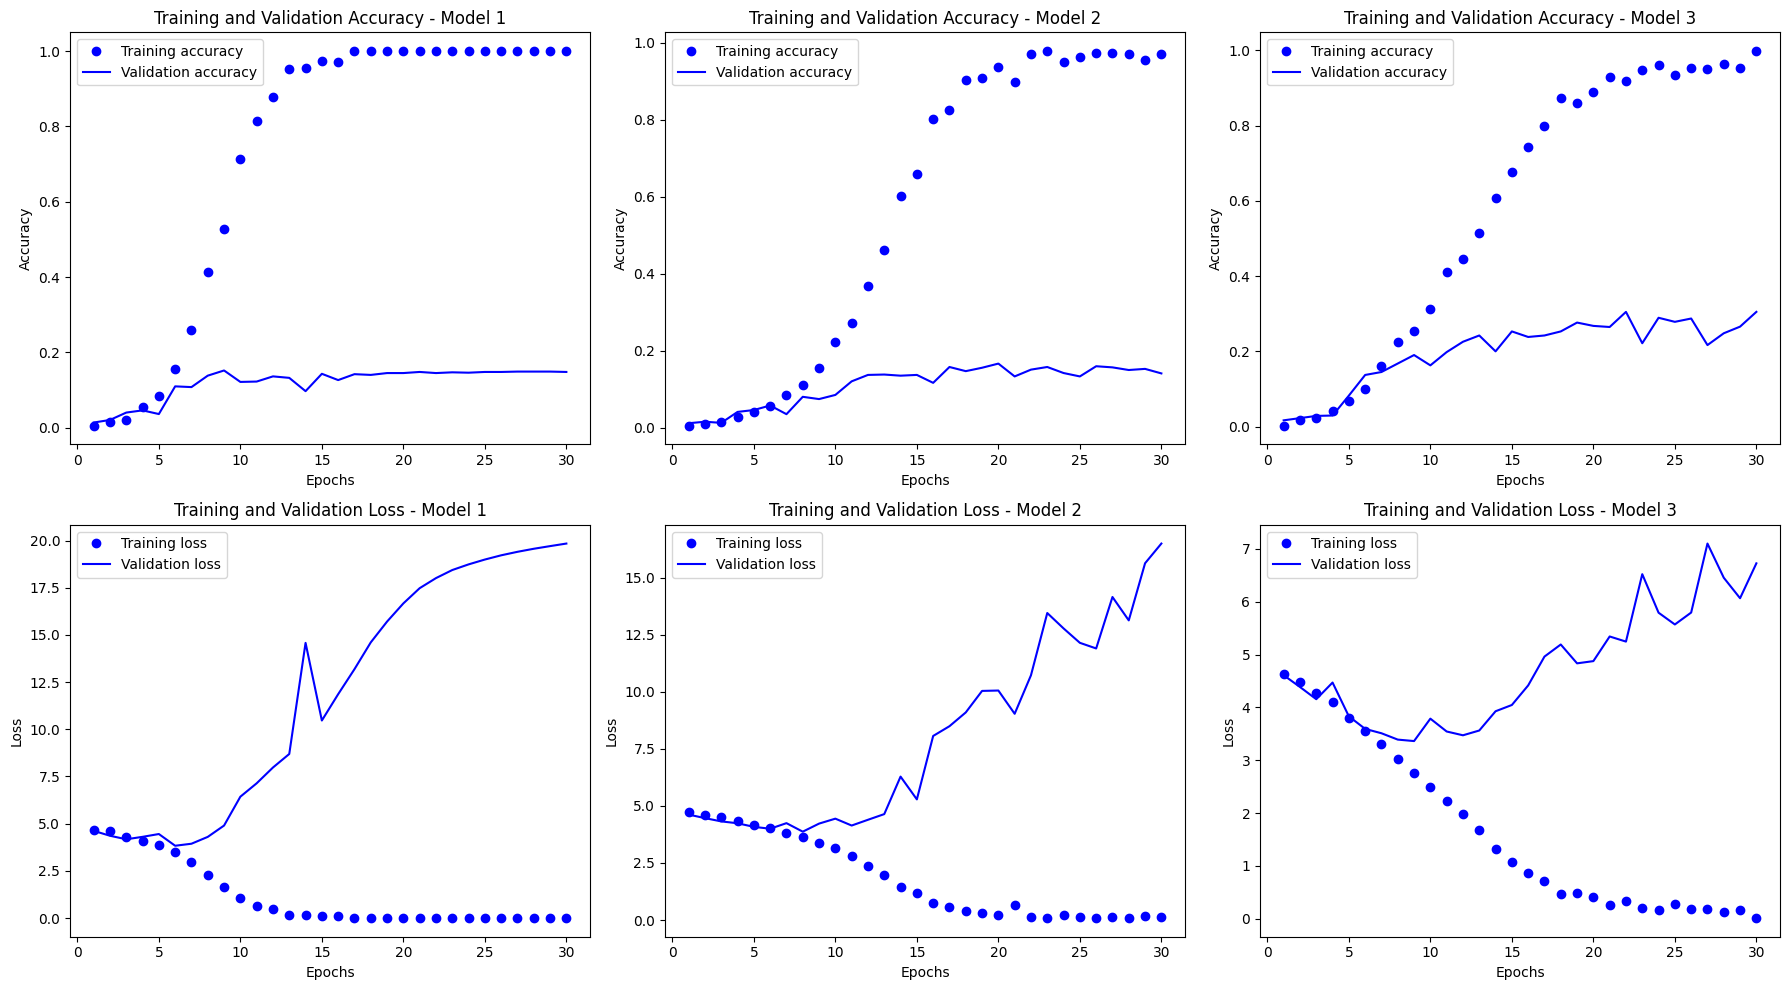

In [ ]:
# take accuracy and loss for each model
models = [loaded_history_model1, loaded_history_model2, loaded_history_model3]
titles = ["Model 1", "Model 2", "Model 3"]

# create skeleton for the plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2 rows, 3 columns

# loop over models and plot
for i, history in enumerate(models):
    accuracy = history["accuracy"] # metric
    val_accuracy = history["val_accuracy"]
    loss = history["loss"] # loss function
    val_loss = history["val_loss"]

    # num epochs
    epochs = range(1, len(accuracy) + 1)

    # plot our metric
    ax1 = axes[0, i]
    ax1.plot(epochs, accuracy, "bo", label="Training accuracy")
    ax1.plot(epochs, val_accuracy, "b", label="Validation accuracy")
    ax1.set_title(f"Training and Validation Accuracy - {titles[i]}")
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # plot loss
    ax2 = axes[1, i]
    ax2.plot(epochs, loss, "bo", label="Training loss")
    ax2.plot(epochs, val_loss, "b", label="Validation loss")
    ax2.set_title(f"Training and Validation Loss - {titles[i]}")
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()

# adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Observations

None of the three models performed amazingly well. All are overfitting.

Model 1 only ever achieve a validation accuracy of about ~0.2, which is exceedenigly low.
The highest validation accuracy across the models was ~0.35, given by our 3rd model, but even this is still quite low.

The fact that training accuracy on all three models is pretty high tells me that the model is, to some extent, overfitting to the training data, and struggling with generalizing to the validation data. In part, this may be due to the fact that the dataset has 102 output classification possibilites, which is a very high number.

Though no model is excellent,  Model 3 is significantly better, as its training accuracy slope is more gradual within 30 epochs, and the validation accuracy also continues climbing instead of plateauing after the first 15 epochs (as in the first 2 models).

 ### QUESTION 1.3
 Augment your data and rerun your model with 50 epochs. Discuss the results. Did you notice improvement? Was it worth the computational expense?

In [ ]:
# data augmentation was a challenge. Discussed in the observations after this model.

# simple augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),  # horizontal flipping to a random 50% of images
        layers.RandomRotation(0.1), # rotate by factor of +- 0.1
        layers.RandomZoom(0.2), # zoom
    ]
)



# other augmentation attempts...
# not great for flowers dataset. further explored later

#data_augmentation = keras.Sequential(
#    [
#        layers.RandomFlip("horizontal"),     # Randomly flips images horizontally (50% chance)
#        layers.RandomRotation(0.1),          # Randomly rotates images by ±10%
#        layers.RandomZoom(0.2),              # Randomly zooms in/out by ±20%
#        layers.RandomContrast(0.1),          # Adjusts contrast randomly
#        layers.RandomTranslation(0.1, 0.1)   # Randomly shifts images by 10%
#    ]
#)


In [ ]:
# back to our 'best' model,
#but now with augmented data
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs) # we add the Augmented Data here
x = layers.Rescaling(1./255)(inputs)

# Apply padding to avoid shrinking too fast
x = layers.Conv2D(filters=32, kernel_size=3, strides=2, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=64, kernel_size=3, strides=1, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=128, kernel_size=3, strides=2, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=256, kernel_size=3, strides=1, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=256, kernel_size=3, strides=1, padding="same", activation="relu")(x)
x = layers.Flatten()(x)

outputs = layers.Dense(102, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
# compile the model
model.compile(loss="categorical_crossentropy",  # loss function for multiclass
              optimizer="rmsprop",  # optimizer that auto adjusts learning rate during backprop. Widely used in CNNs. (alternative to "adam").
              metrics=["accuracy"])            # Performance metric.

# callback for best model iteration
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/ColabNotebooks/GU_Callbacks/PS2_CNN_Model3_AugmentedData.keras",
        save_best_only=True,
        monitor="val_loss")
]

# fit
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.0122 - loss: 4.6241 - val_accuracy: 0.0186 - val_loss: 4.4324
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.0220 - loss: 4.3658 - val_accuracy: 0.0245 - val_loss: 4.3266
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.0235 - loss: 4.2510 - val_accuracy: 0.0422 - val_loss: 4.1229
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0358 - loss: 4.0734 - val_accuracy: 0.0471 - val_loss: 4.1585
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.0546 - loss: 3.9566 - val_accuracy: 0.0794 - val_loss: 3.9031
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.0998 - loss: 3.7007 - val_accuracy: 0.1049 - val_loss: 3.7218
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.1319 - loss: 3.4127 - val_accuracy: 0.1196 - val_loss: 3.7438
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1828 - loss: 3.1733 - val_accuracy: 0.1363 - 

In [ ]:
# save data
with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_model3aug_history.json', 'w') as f:
    json.dump(history.history, f)

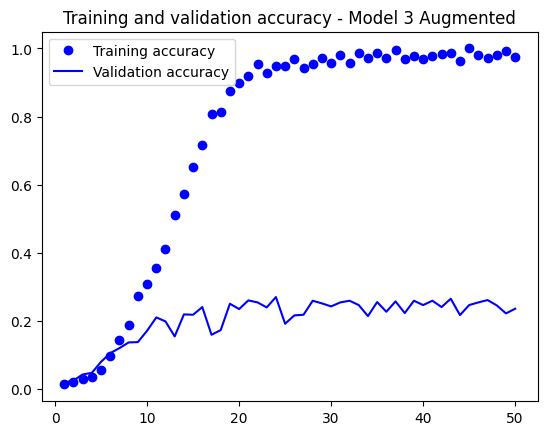

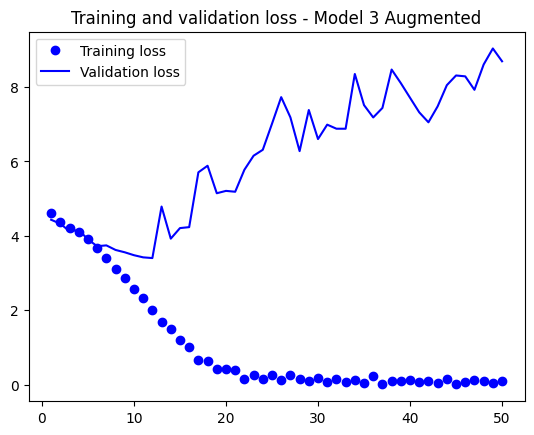

In [ ]:
# read data
with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_model3aug_history.json', 'r') as f:
    loaded_history_model3aug = json.load(f)



# let's plot some metrics
accuracy = loaded_history_model3aug["accuracy"]
val_accuracy = loaded_history_model3aug["val_accuracy"]
loss = loaded_history_model3aug["loss"]
val_loss = loaded_history_model3aug["val_loss"]

# num epochs
epochs = range(1, len(accuracy) + 1)

# plot training and validation accuracy
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy - Model 3 Augmented")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss - Model 3 Augmented")
plt.legend()
plt.show()

## Observations
Normally, I would have expected to see some real improvement between the non-augmented data and augmented data models. In our example in class, it made a ~15 point difference, which is very nice, but here it actually made a negative difference!

I ran this augmented version first with
Horizontal RandomFlip (50%)
RandomRotation of 0.1
and RandomZoom of 0.2, but was dissatisfied with the results.

I thought that the augmentations had perhaps been too severe for the dataset we're dealing with (flowers, which sometimes took up the whole image and thus couldn't really be zoomed-into etc), and so I tried another model with
Horizontal RandomFlip (50%)
RandomRotation of 0.05
and NO RandomZoom

However, this model performed no better than the original augmented one, so I returned to the original parameter.

Perhaps the model would benefit from more than 50 epochs, but I don't think so because it is already overfitting really intensely.

# Task 2 - German Traffic Signs

In [1]:
# for reproducible results
np.random.seed(42)

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# unzip our thirty nine thousand images onto drive for access
# and their label csvs
!unzip '/content/drive/MyDrive/ColabNotebooks/GU_Data/archive.zip'

Streaming output truncated to the last 5000 lines.
  inflating: train/5/00005_00053_00010.png  
  inflating: train/5/00005_00053_00011.png  
  inflating: train/5/00005_00053_00012.png  
  inflating: train/5/00005_00053_00013.png  
  inflating: train/5/00005_00053_00014.png  
  inflating: train/5/00005_00053_00015.png  
  inflating: train/5/00005_00053_00016.png  
  inflating: train/5/00005_00053_00017.png  
  inflating: train/5/00005_00053_00018.png  
  inflating: train/5/00005_00053_00019.png  
  inflating: train/5/00005_00053_00020.png  
  inflating: train/5/00005_00053_00021.png  
  inflating: train/5/00005_00053_00022.png  
  inflating: train/5/00005_00053_00023.png  
  inflating: train/5/00005_00053_00024.png  
  inflating: train/5/00005_00053_00025.png  
  inflating: train/5/00005_00053_00026.png  
  inflating: train/5/00005_00053_00027.png  
  inflating: train/5/00005_00053_00028.png  
  inflating: train/5/00005_00053_00029.png  
  inflating: train/5/00005_00054_00000.png  
  in

In [2]:
# directory where data sits now
data_dir = '/content'
train_path = '/content/Train'
#test_path = '../input/gtsrb-german-traffic-sign/'


# resizing the images to 30x30x3 for regular models
# resizing the images to 32x32x3 for VGG
# NOTE ON THIS IN DISCUSSION AT END
IMG_HEIGHT = 30
IMG_WIDTH = 30
#IMG_HEIGHT = 32
#IMG_WIDTH = 32
#IMG_HEIGHT = 180
#IMG_WIDTH = 180
channels = 3

# num classes
NUM_CATEGORIES = len(os.listdir(train_path))
NUM_CATEGORIES

43

In [3]:
# all our labels
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)',
            2:'Speed limit (50km/h)',
            3:'Speed limit (60km/h)',
            4:'Speed limit (70km/h)',
            5:'Speed limit (80km/h)',
            6:'End of speed limit (80km/h)',
            7:'Speed limit (100km/h)',
            8:'Speed limit (120km/h)',
            9:'No passing',
            10:'No passing veh over 3.5 tons',
            11:'Right-of-way at intersection',
            12:'Priority road',
            13:'Yield',
            14:'Stop',
            15:'No vehicles',
            16:'Veh > 3.5 tons prohibited',
            17:'No entry',
            18:'General caution',
            19:'Dangerous curve left',
            20:'Dangerous curve right',
            21:'Double curve',
            22:'Bumpy road',
            23:'Slippery road',
            24:'Road narrows on the right',
            25:'Road work',
            26:'Traffic signals',
            27:'Pedestrians',
            28:'Children crossing',
            29:'Bicycles crossing',
            30:'Beware of ice/snow',
            31:'Wild animals crossing',
            32:'End speed + passing limits',
            33:'Turn right ahead',
            34:'Turn left ahead',
            35:'Ahead only',
            36:'Go straight or right',
            37:'Go straight or left',
            38:'Keep right',
            39:'Keep left',
            40:'Roundabout mandatory',
            41:'End of no passing',
            42:'End no passing veh > 3.5 tons' }

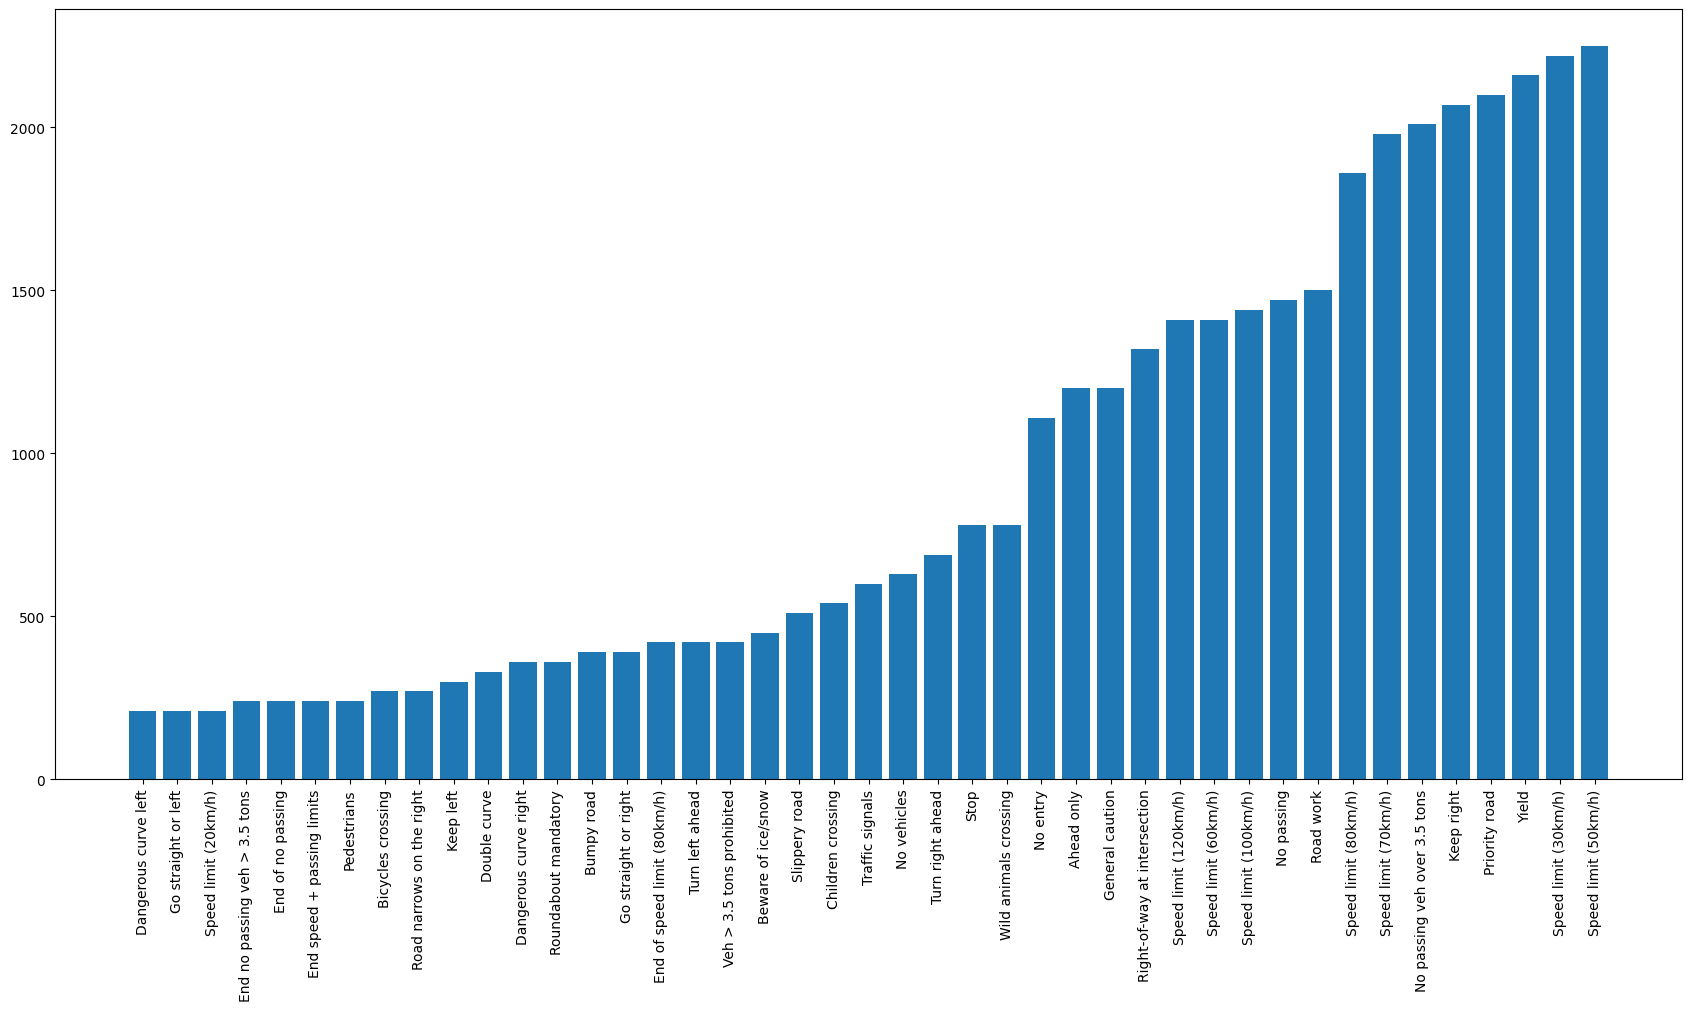

In [4]:
# getting an idea of the distribution of our data
folders = os.listdir(train_path)

train_number = []
class_num = []

for folder in folders:
    train_files = os.listdir(train_path + '/' + folder)
    train_number.append(len(train_files))
    class_num.append(classes[int(folder)])

# sorting the dataset on the basis of number of images in each class
zipped_lists = zip(train_number, class_num)
sorted_pairs = sorted(zipped_lists)
tuples = zip(*sorted_pairs)
train_number, class_num = [ list(tuple) for tuple in  tuples]

# plotting the number of images in each class
plt.figure(figsize=(21,10))
plt.bar(class_num, train_number)
plt.xticks(class_num, rotation='vertical')
plt.show()

In [5]:
# taking our images and prepping for model

# initialize some empty lists
image_data = []
image_labels = []

# use directory of images to resize images and fetch labels
for i in range(NUM_CATEGORIES):
    path = data_dir + '/Train/' + str(i)
    images = os.listdir(path)

    for img in images:
        try:
            image = cv2.imread(path + '/' + img)
            image_fromarray = Image.fromarray(image, 'RGB')
            resize_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH)) # resize
            image_data.append(np.array(resize_image))
            image_labels.append(i) # labels
        except:
            print("Error in " + img)

# changing the list to numpy array for correct format
image_data = np.array(image_data)
image_labels = np.array(image_labels)

print(image_data.shape, image_labels.shape)

(39209, 32, 32, 3) (39209,)


In [6]:
# shuffle for better training
shuffle_indexes = np.arange(image_data.shape[0])
np.random.shuffle(shuffle_indexes)
image_data = image_data[shuffle_indexes] # setting images
image_labels = image_labels[shuffle_indexes] # and labels

In [7]:
# setting train and val datasets
X_train, X_val, y_train, y_val = train_test_split(image_data,
                                                  image_labels,
                                                  test_size=0.3, # unusual split, 70/30, but we have many many many images
                                                  random_state=42,
                                                  shuffle=True)

X_train = X_train/255
X_val = X_val/255

print("X_train.shape", X_train.shape)
print("X_valid.shape", X_val.shape)
print("y_train.shape", y_train.shape)
print("y_valid.shape", y_val.shape)

X_train.shape (27446, 32, 32, 3)
X_valid.shape (11763, 32, 32, 3)
y_train.shape (27446,)
y_valid.shape (11763,)


In [8]:
y_train = keras.utils.to_categorical(y_train, NUM_CATEGORIES) # to categorical instead of numerical
y_val = keras.utils.to_categorical(y_val, NUM_CATEGORIES)

print(y_train.shape)
print(y_val.shape)

(27446, 43)
(11763, 43)


In [9]:
BATCH_SIZE = 32  # batch size for each

# combine X and Y into a tf.data.Dataset,
# since our functions later one want them together
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)) # for train set
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)) # and for val set

# chuffle, batch, and prefetch the datasets (for better performance)
train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Note on Model 1 for Germany:
This model was written for image size 180x180 under a completely different data loading, pre-processing, ImageDataGenerator structure etc.
However, when I actually fit and trained the model, its accuracy for validation was something like 0.00000e*-12, meaning that something had gone terribly wrong in my pre-processing.

After much investigation, it seemed like my validation dataset had not been properly labeled (by my own fault), and so there was no way to correctly calculate an accuracy score.

I tried for a very, very long time to fix this, but under the structure that I had used in pre-processing, it proved to be much more trouble than it was worth. After some hours, I decided to just re-start this section (German Traffic Data) but retain the performance (0.000 Val Accuracy) of this first model, just as something to compare the second 2 models against. It is important to note that here the model takes 180x180 and i later switch to 30x30 and 32x32. I know this is not good. Constraints of the code forced me to. I will further explain in a bit.

In [12]:
#@title Model Germany 1
inputs = keras.Input(shape=(180, 180, 3))  # size for our images, and 3 channels of input (RGB)
x = layers.Rescaling(1./255)(inputs)        # rescale the range of 255 for colour values to [0,1]

x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)     # First Conv layer. We instruct the model to use 32 3x3 filters. The activation function is ReLU. The stride is the default 1. No padding is used.
x = layers.MaxPooling2D(pool_size=2)(x)   # The pooling layer will reduce the size by 2. Technically, the command is to use a 2x2 window with a stride of 2 to downsample the feature maps (essentially halving the dimensions). No effect on channels.
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)     # Second Conv layer. Same as the first. Notice how the filters have doubled.
x = layers.MaxPooling2D(pool_size=2)(x)     # Second pooling layer. Same as the first.
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)   # Third Conv layer. Filters are doubled.
x = layers.MaxPooling2D(pool_size=2)(x)  # Third pooling layer. Same as the others.
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)    # Fourth Conv layer. Filters are doubled.
x = layers.MaxPooling2D(pool_size=2)(x)    # Fourth pooling layer. Same as the others.
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)    # Fifth and final Conv layer. Final filter number: 256.
x = layers.Flatten()(x) # flatten tensors for the final computation
outputs = layers.Dense(43, activation="softmax")(x) # dense (fully connected) output layer with softmax (multiclass classification)
model = keras.Model(inputs=inputs, outputs=outputs)

In [13]:
#@title Model Germany 1 compile and train
# compile the model
model.compile(loss="categorical_crossentropy",  # loss function for multiclass
              optimizer="rmsprop",  # optimizer that auto adjusts learning rate during backprop. Widely used in CNNs. (alternative to "adam").
              metrics=["accuracy"])            # Performance metric.



In [11]:
#@title Model Germany 1 callback and fit
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/ColabNotebooks/GU_Callbacks/PS2_CNN_GermanyMod1.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1103/1103 ━━━━━━━━━━━━━━━━━━━━ 80s 65ms/step - accuracy: 0.0572 - loss: 3.4821 - val_accuracy: 0.0000e+00 - val_loss: 6.2842
Epoch 2/30
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 60s 51ms/step - accuracy: 0.0587 - loss: 3.4435 - val_accuracy: 0.0000e+00 - val_loss: 6.4684
Epoch 3/30
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.0591 - loss: 3.4423 - val_accuracy: 0.0000e+00 - val_loss: 6.7859
Epoch 4/30
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 95s 62ms/step - accuracy: 0.0630 - loss: 3.4420 - val_accuracy: 0.0000e+00 - val_loss: 6.8870
Epoch 5/30
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 54s 48ms/step - accuracy: 0.0568 - loss: 3.4482 - val_accuracy: 0.0000e+00 - val_loss: 7.0245
Epoch 6/30
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 51s 46ms/step - accuracy: 0.0614 - loss: 3.4378 - val_accuracy: 0.0000e+00 - val_loss: 7.3374
Epoch 7/30
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 50s 45ms/step - accuracy: 0.0601 - loss: 3.4398 - val_accuracy: 0.0000e+00 - val_loss: 7.3929
Epoch 8/30
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 48s 44ms/step - a

In [12]:
#@title Model Germany 1 save data

with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_Germanymod1_history.json', 'w') as f:
    json.dump(history.history, f)


For Germany models 2 and 3, I used 30x30 resizing. Partially, this is because there is a huge amount of variation in the sizes of the images of traffic signs (some are 50x50, some 25x20, some 70x20...), and 180x180 did not make sense to me.
More importantly, however, my RAM kept crashing when using 180x180.
I know now that this is often an indication that the images are not being loaded correctly (ie: not using ImageDataGenerator or some tool that helps reduce the memory load of the image representation). However, even when using the correct libraries and ImageDataGenerator, the 180x180 attempts results in crashes and malfunctions. I simply could not get it to work, so I opted for this lower-resolution representation.

Lower-definition representations of images (which, between the 180x180 and 30x30 representations is a magnitude of 36 times the resolution if we consider the number of pixels) are surely going to have less data that we can train on. This absolutely affects the performance of my models, and it becomes clear once I plot accuracy that these unlucky models never had a chance. The results are atrocious. But again, I simply could not find a way to get 180 to work with such a massive dataset.

Another option would have been to only take a subset of the dataset (ie: not the full ~36000 training images, but perhaps only 3000 or so), but the fact that there are many folder, and as is evidenced by the frequency distribution of labels (eg: Speed Limit has > 2000 example images while Dangerous Turn has < 250), I did not feel that I was in a knowledgeable-enough position to make that decisions.

Thus, my models are terrible.

In [12]:
#@title Germany Model 2

# Input layer with 30x30 RGB images
inputs = keras.Input(shape=(30, 30, 3))

# Rescaling layer to normalize pixel values
x = layers.Rescaling(1./255)(inputs)

# First Conv layer: 32 filters, 3x3 kernel
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu", padding='same')(x)
x = layers.MaxPooling2D(pool_size=2)(x)  # Pooling: Reduce size to 15x15

# Second Conv layer: 64 filters, 3x3 kernel
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding='same')(x)
x = layers.MaxPooling2D(pool_size=2)(x)  # Pooling: Reduce size to 7x7

# Third Conv layer: 128 filters, 3x3 kernel
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding='same')(x)

# Fourth Conv layer: 128 filters, 3x3 kernel
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding='same')(x)

# Fifth Conv layer: 256 filters, 3x3 kernel
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding='same')(x)
x = layers.MaxPooling2D(pool_size=2)(x)  # Pooling: Reduce size to 3x3

# Flatten and Dense layers
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
outputs = layers.Dense(43, activation="softmax")(x)  # Output layer for multi-class classification

model = keras.Model(inputs=inputs, outputs=outputs)

In [13]:
# compile the model
model.compile(loss="categorical_crossentropy",  # loss function for multiclass
              optimizer="rmsprop",  # optimizer that auto adjusts learning rate during backprop. Widely used in CNNs. (alternative to "adam").
              metrics=["accuracy"])            # Performance metric.


In [14]:
#@title Germany Model 2 callback and training
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/ColabNotebooks/GU_Callbacks/PS2_CNN_GermanyMod2.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks)

Epoch 1/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.0509 - loss: 3.5281 - val_accuracy: 0.0555 - val_loss: 3.4858
Epoch 2/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.0559 - loss: 3.4997 - val_accuracy: 0.0553 - val_loss: 3.4835
Epoch 3/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.0545 - loss: 3.4908 - val_accuracy: 0.0597 - val_loss: 3.4830
Epoch 4/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0542 - loss: 3.4884 - val_accuracy: 0.0597 - val_loss: 3.4822
Epoch 5/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0559 - loss: 3.4923 - val_accuracy: 0.0555 - val_loss: 3.4872
Epoch 6/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0522 - loss: 3.4905 - val_accuracy: 0.0597 - val_loss: 3.4812
Epoch 7/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0530 - loss: 3.4837 - val_accuracy: 0.0553 - val_loss: 3.4807
Epoch 8/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0558 - loss: 3.4895 - val_accuracy:

In [15]:
with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_Germanymod2_history.json', 'w') as f:
    json.dump(history.history, f)


In [17]:
#@title Germany Model 3

# Input layer for 30x30 RGB images
inputs = keras.Input(shape=(30, 30, 3))
x = layers.Rescaling(1./255)(inputs)

# First Conv layer with stride 2 and padding to preserve dimensions
x = layers.Conv2D(filters=32, kernel_size=3, strides=2, padding="same", activation="relu")(x)  # Output: 15x15
x = layers.MaxPooling2D(pool_size=2, padding="same")(x)  # Output: 8x8

# Second Conv layer with stride 1
x = layers.Conv2D(filters=64, kernel_size=3, strides=1, padding="same", activation="relu")(x)  # Output: 8x8
x = layers.MaxPooling2D(pool_size=2, padding="same")(x)  # Output: 4x4

# Third Conv layer with stride 2
x = layers.Conv2D(filters=128, kernel_size=3, strides=2, padding="same", activation="relu")(x)  # Output: 2x2
x = layers.MaxPooling2D(pool_size=2, padding="same")(x)  # Output: 1x1

# Fourth Conv layer with stride 1
x = layers.Conv2D(filters=256, kernel_size=3, strides=1, padding="same", activation="relu")(x)  # Output: 1x1

# Fifth Conv layer with stride 1
x = layers.Conv2D(filters=256, kernel_size=3, strides=1, padding="same", activation="relu")(x)  # Output: 1x1

# Flatten the output and apply a Dense layer for classification
x = layers.Flatten()(x)
outputs = layers.Dense(43, activation="softmax")(x)  # Output layer for 43 classes

# Define the model
model = keras.Model(inputs=inputs, outputs=outputs)

In [18]:
# compile the model
model.compile(loss="categorical_crossentropy",  # loss function for multiclass
              optimizer="rmsprop",  # optimizer that auto adjusts learning rate during backprop. Widely used in CNNs. (alternative to "adam").
              metrics=["accuracy"])            # Performance metric.


callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/ColabNotebooks/GU_Callbacks/PS2_CNN_GermanyMod3.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks)

Epoch 1/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.0535 - loss: 3.5333 - val_accuracy: 0.0539 - val_loss: 3.4841
Epoch 2/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.0538 - loss: 3.4959 - val_accuracy: 0.0553 - val_loss: 3.4831
Epoch 3/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0551 - loss: 3.4958 - val_accuracy: 0.0553 - val_loss: 3.4840
Epoch 4/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.0569 - loss: 3.4915 - val_accuracy: 0.0553 - val_loss: 3.4819
Epoch 5/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.0529 - loss: 3.4952 - val_accuracy: 0.0553 - val_loss: 3.4819
Epoch 6/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0570 - loss: 3.4923 - val_accuracy: 0.0597 - val_loss: 3.4813
Epoch 7/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.0565 - loss: 3.4856 - val_accuracy: 0.0597 - val_loss: 3.4815
Epoch 8/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.0576 - loss: 3.4969 - val_accuracy:

In [19]:
with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_Germanymod3_history.json', 'w') as f:
    json.dump(history.history, f)


In [20]:
#@title Plot three models together
with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_Germanymod1_history.json', 'r') as f:
    loaded_history_Germanymod1 = json.load(f)

with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_Germanymod2_history.json', 'r') as f:
    loaded_history_Germanymod2 = json.load(f)

with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_Germanymod3_history.json', 'r') as f:
    loaded_history_Germanymod3 = json.load(f)

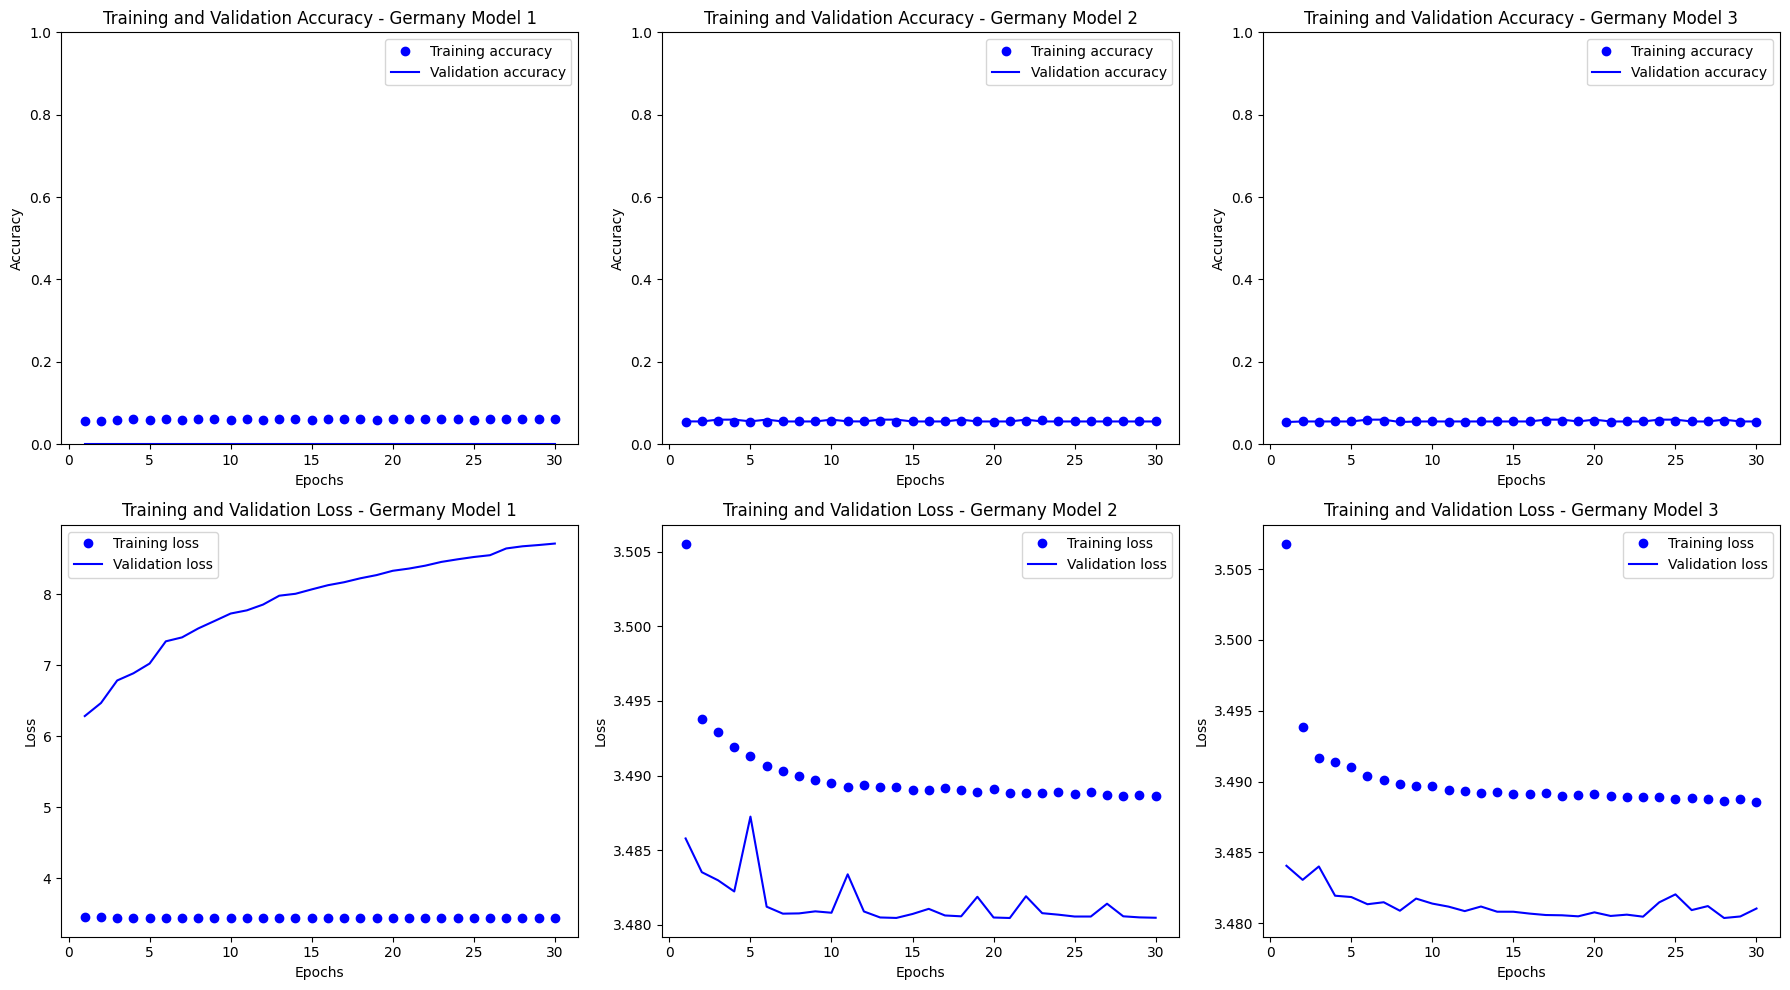

In [22]:
# extract accuracy and loss for each model
models = [loaded_history_Germanymod1, loaded_history_Germanymod2, loaded_history_Germanymod3]
titles = ["Germany Model 1", "Germany Model 2", "Germany Model 3"]

# create a skeleton figure for the plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2 rows, 3 columns

# loop over models and plot
for i, history in enumerate(models):
    accuracy = history["accuracy"]
    val_accuracy = history["val_accuracy"]
    loss = history["loss"]
    val_loss = history["val_loss"]

    # set the range for the number of epochs
    epochs = range(1, len(accuracy) + 1)

    # plot training and validation accuracy
    ax1 = axes[0, i]
    ax1.plot(epochs, accuracy, "bo", label="Training accuracy")
    ax1.plot(epochs, val_accuracy, "b", label="Validation accuracy")
    ax1.set_title(f"Training and Validation Accuracy - {titles[i]}")
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim([0, 1])  # set y-axis range from 0 to 1, because it can be deceptive otherwise
    ax1.legend()

    # plot training and validation loss
    ax2 = axes[1, i]
    ax2.plot(epochs, loss, "bo", label="Training loss")
    ax2.plot(epochs, val_loss, "b", label="Validation loss")
    ax2.set_title(f"Training and Validation Loss - {titles[i]}")
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()

# adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Again, the first model clearly learned nothing, due (most likely) to what I mentioned about missing labels.
The second two also performed very poorly, but at least the loss indicatres that something was being learned, even if very poorly.

Now we move on to VGG16 Model Leveraging

In [10]:

# had horrible troubles with version of this...
#import tensorflow_addons as tfa

# had to try a few different things, none of which were waterproof
# settled on this, but im commenting it out because it threw errors in my final runs
#!pip install tensorflow==2.13.0 tensorflow-addons==0.20.0

# leaving the most recent error message here


/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.10.0 and strictly below 2.13.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.13.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

ImportError: cannot import name 'tf_utils' from 'keras.utils' (/usr/local/lib/python3.10/dist-packages/keras/utils/__init__.py)

In [11]:
# as mentioned earlier, we have to use at least 32x32 for VGG to work

conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet", # using weights resulting from imagenet training
    include_top=False, # we have our own classification goals (43 german sign classes)
    input_shape=(32, 32, 3)) # our classic setup

conv_base.summary()


58889256/58889256 [==============================] - 0s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 32, 32, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 32, 32, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 16, 16, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 16, 16, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 16, 16, 128)       147584    
                                                              

In [12]:
# freeze the convolutional base
conv_base  = keras.applications.vgg16.VGG16(
    weights="imagenet", # this is us 'leveraging' the 1.4 million labeled images
    include_top=False) # we have our own classes, so we don't want this top dense layer
conv_base.trainable = False # freeze!

In [13]:
# checking that our freezing works
conv_base.trainable = True
print("This is the number of trainable weights "
      "before freezing the conv base:", len(conv_base.trainable_weights)) # should be a nonzero number

conv_base.trainable = False
print("This is the number of trainable weights "
      "after freezing the conv base:", len(conv_base.trainable_weights)) # should be zero

This is the number of trainable weights before freezing the conv base: 26
This is the number of trainable weights after freezing the conv base: 0


In [20]:
# adding a data augmentation stage and a classifier to the convolutional base
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)                                                   # Applying Data Augmentation in a pretrained model.
x = keras.applications.vgg16.preprocess_input(x)                                # Input value scaling.
x = conv_base(x)                                                                # Retaining the convolutional base.
x = layers.Flatten()(x)                                                         # Flattening the final convolutional output.
x = layers.Dense(256)(x)                                                        # Adding a dense final layer.
x = layers.Dropout(0.5)(x)                                                      # Introducing dropout (50%) as our regularization to avoid overfitting.
outputs = layers.Dense(43, activation="softmax")(x)                              # Output layer with the sigmoid activation function.
model = keras.Model(inputs, outputs)

# compile the model
model.compile(loss="categorical_crossentropy",  # loss function for multiclass
              optimizer="rmsprop",  # optimizer that auto adjusts learning rate during backprop. Widely used in CNNs. (alternative to "adam").
              metrics=["accuracy"])            # Performance metric.


In [21]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/ColabNotebooks/GU_Callbacks/PS2_VGG16_AugmentedGermany.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks)

# VGG did not want to work, and unfortunately I have spent too many hours on this pset.
# Though it saddends me, I recognize my defeat and leave it here.

Epoch 1/50
858/858 [==============================] - ETA: 0s - loss: 4.1009 - accuracy: 0.0632

ValueError: The following argument(s) are not supported with the native Keras format: ['options']

In [ ]:
#with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_VGG16Germany_history.json', 'w') as f:
    #json.dump(history.history, f)

#with open('/content/drive/MyDrive/ColabNotebooks/GU_Data/PS2_VGG16Germany_history.json', 'r') as f:
    #loaded_history_VGG16Germany = json.load(f)

# REFERENCES/ TOOLS USED
GTSRB - CNN (98% Test Accuracy). (n.d.). Retrieved October 14, 2024, from https://kaggle.com/code/shivank856/gtsrb-cnn-98-test-accuracy

GTSRB - German Traffic Sign Recognition Benchmark. (n.d.). Retrieved October 14, 2024, from https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

OpenAI. (2024). ChatGPT (GPT-4o) [Large language model]. https://chat.openai.com/chat

Visual Geometry Group—University of Oxford. (n.d.). Retrieved October 14, 2024, from https://www.robots.ox.ac.uk/~vgg/data/flowers/102/
